# Frozen Wolffia Transfer Model v1: Visual Validation

## tl;dr

The model carried forward for the first real *Wolffia australiana* analysis is the **340-feature, ortholog-restricted, calibrated dual-model consensus**. A provisional label is emitted only when logistic regression and random forest agree and both calibrated confidences are at least **0.60**; otherwise the cell is `ambiguous`.

On the cluster-held-out Arabidopsis pseudo-label benchmark, this rule accepts **30.4%** of cells and is correct for **95.3%** of accepted pseudo-labels. These are selective pseudo-label recovery metrics—not estimates of true Wolffia cell-type accuracy. The model remains provisional until tested on real Wolffia data.

## Context & Methods

This notebook is a reader-facing companion to `docs/final_wolffia_transfer_model.md`. It visualizes saved, reproducible artifacts produced by:

- `scripts/27_root_reference_consensus.py`
- `scripts/30_transfer_model_benchmark_and_marker_audit.py`
- `scripts/31_freeze_wolffia_transfer_model.py`

### Key Assumptions

1. Arabidopsis cluster labels are marker-derived pseudo-labels, not independent ground truth.
2. Only high- or medium-confidence reciprocal protein mappings enter the strict Wolffia classifier.
3. Calibration and threshold evaluation use the existing cluster-held-out predictions.
4. The synthetic perturbation test checks software behavior and rejection safety. Its sampled cells contributed to model fitting, so it is not an independent biological validation.
5. The trained classifier predicts three coarse programs; the broader eight-program ontology remains an interpretation framework, not an eight-class supervised model.

### 1. Setup and source locations

The notebook locates the repository whether it is launched from the project root or from `notebooks/`. All displayed results come from saved CSV/JSON artifacts rather than copied values.

In [1]:
from pathlib import Path
import hashlib
import json
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown

TOKENS = {
    "surface": "#FCFCFD", "panel": "#FFFFFF", "ink": "#1F2430",
    "muted": "#6F768A", "grid": "#E6E8F0", "axis": "#D7DBE7",
}
COLORS = {
    "blue": "#A3BEFA", "blue_dark": "#2E4780", "gold": "#FFE15B",
    "gold_dark": "#736422", "orange": "#F0986E", "neutral": "#C5CAD3",
    "neutral_dark": "#464C55", "neutral_light": "#E2E5EA",
}
sns.set_theme(style="whitegrid", context="notebook", rc={
    "figure.facecolor": TOKENS["surface"], "axes.facecolor": TOKENS["panel"],
    "axes.edgecolor": TOKENS["axis"], "axes.labelcolor": TOKENS["ink"],
    "grid.color": TOKENS["grid"], "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
})

def add_chart_header(fig, ax, title, subtitle):
    """Notebook adaptation of the shared static-chart header template."""
    ax.set_title("")
    fig.subplots_adjust(top=0.78)
    left = ax.get_position().x0
    fig.text(left, 0.97, textwrap.fill(title, 76), ha="left", va="top",
             fontsize=13, fontweight="semibold", color=TOKENS["ink"])
    fig.text(left, 0.90, textwrap.fill(subtitle, 112), ha="left", va="top",
             fontsize=9, color=TOKENS["muted"])
    sns.despine(ax=ax)
pd.set_option("display.max_columns", 30)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "results").exists() else cwd.parent
if not (PROJECT_ROOT / "results").exists():
    raise FileNotFoundError("Could not locate the project root.")

FINAL_DIR = PROJECT_ROOT / "results" / "final_wolffia_transfer_model"
AUDIT_DIR = PROJECT_ROOT / "results" / "transfer_model_audit"
RESTRICTED_DIR = PROJECT_ROOT / "results" / "root_reference_consensus_ortholog_restricted"

source_paths = {
    "manifest": FINAL_DIR / "final_model_manifest.json",
    "thresholds": FINAL_DIR / "confidence_threshold_audit.csv",
    "robustness": FINAL_DIR / "synthetic_robustness.csv",
    "markers": FINAL_DIR / "frozen_marker_evidence.csv",
    "model_metrics": AUDIT_DIR / "model_metric_comparison.csv",
    "oof_predictions": RESTRICTED_DIR / "cluster_heldout_predictions.csv",
}
missing = [str(p) for p in source_paths.values() if not p.exists()]
assert not missing, f"Missing required artifacts: {missing}"
print(f"Project root: {PROJECT_ROOT}")
print(f"Validated {len(source_paths)} required source artifacts.")

Project root: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
Validated 6 required source artifacts.


## Data

### 2. Load the frozen artifacts and record provenance

The table below records each input's repository-relative path, size, modification time, and SHA-256 digest. This makes the executed notebook traceable to the exact local artifacts it summarized.

In [2]:
with open(source_paths["manifest"], encoding="utf-8") as handle:
    manifest = json.load(handle)
thresholds = pd.read_csv(source_paths["thresholds"])
robustness = pd.read_csv(source_paths["robustness"])
markers = pd.read_csv(source_paths["markers"])
model_metrics = pd.read_csv(source_paths["model_metrics"])
oof = pd.read_csv(source_paths["oof_predictions"])

provenance = []
for name, path in source_paths.items():
    stat = path.stat()
    provenance.append({
        "source": name,
        "path": str(path.relative_to(PROJECT_ROOT)),
        "bytes": stat.st_size,
        "modified_utc": pd.Timestamp(stat.st_mtime, unit="s", tz="UTC").isoformat(),
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest()[:16],
    })
provenance = pd.DataFrame(provenance)
display(provenance)

,source,path,bytes,modified_utc,sha256
0,manifest,results/final_wolffia_transfer_model/final_mod...,1776,2026-07-06T20:10:30.445466280+00:00,a0fa963fb75f20f0
1,thresholds,results/final_wolffia_transfer_model/confidenc...,741,2026-07-06T20:10:26.961241007+00:00,fa484de8800f1801
2,robustness,results/final_wolffia_transfer_model/synthetic...,4681,2026-07-06T20:10:29.755428314+00:00,7916d867106df8ad
3,markers,results/final_wolffia_transfer_model/frozen_ma...,15415,2026-07-06T20:10:29.759082794+00:00,7df99256cc4cefce
4,model_metrics,results/transfer_model_audit/model_metric_comp...,1122,2026-07-02T03:04:41.189356565+00:00,22be0892880e6636
5,oof_predictions,results/root_reference_consensus_ortholog_rest...,1675574,2026-07-01T20:17:07.290947437+00:00,b961f625eb930398


### 3. Validate the headline numbers independently

This cell reconstructs the frozen rule directly from the two out-of-fold prediction rows per cell. It checks one-to-one pairing, agreement, thresholding, and the denominator used for acceptance and selective accuracy.

In [3]:
keys = ["fold", "cell_index", "cluster", "true_pseudo_label"]
logistic = (
    oof.loc[oof["model"].eq("logistic_regression"), keys + ["predicted_label", "calibrated_confidence"]]
    .rename(columns={"predicted_label": "lr_label", "calibrated_confidence": "lr_confidence"})
)
forest = (
    oof.loc[oof["model"].eq("random_forest"), keys + ["predicted_label", "calibrated_confidence"]]
    .rename(columns={"predicted_label": "rf_label", "calibrated_confidence": "rf_confidence"})
)
paired = logistic.merge(forest, on=keys, validate="one_to_one")
frozen_threshold = manifest["decision_rule"]["minimum_calibrated_confidence_each_model"]
accepted = (
    paired["lr_label"].eq(paired["rf_label"])
    & paired["lr_confidence"].ge(frozen_threshold)
    & paired["rf_confidence"].ge(frozen_threshold)
)
recomputed = {
    "held_out_cells": len(paired),
    "accepted_cells": int(accepted.sum()),
    "acceptance_rate": float(accepted.mean()),
    "selective_accuracy": float(
        paired.loc[accepted, "lr_label"].eq(paired.loc[accepted, "true_pseudo_label"]).mean()
    ),
}

frozen_row = thresholds.loc[np.isclose(thresholds["confidence_threshold"], frozen_threshold)].iloc[0]
assert recomputed["held_out_cells"] == 4727
assert recomputed["accepted_cells"] == int(frozen_row["n_accepted"])
assert np.isclose(recomputed["acceptance_rate"], frozen_row["acceptance_rate"])
assert np.isclose(recomputed["selective_accuracy"], frozen_row["selective_accuracy"])
assert markers.shape[0] == 45
assert markers[["program", "gene", "gene_id"]].duplicated().sum() == 0

pd.DataFrame([recomputed]).style.format({
    "acceptance_rate": "{:.1%}",
    "selective_accuracy": "{:.1%}",
})

,held_out_cells,accepted_cells,acceptance_rate,selective_accuracy
0,4727,1438,30.4%,95.3%


## Results

### 4. Why the unrestricted model is not the final Wolffia model

The full 2,000-gene models perform better within Arabidopsis. They are retained as an internal benchmark only because most features lack strict one-to-one Wolffia mappings. The 340-feature comparison quantifies the discrimination sacrificed to obtain a technically defensible cross-species feature space.

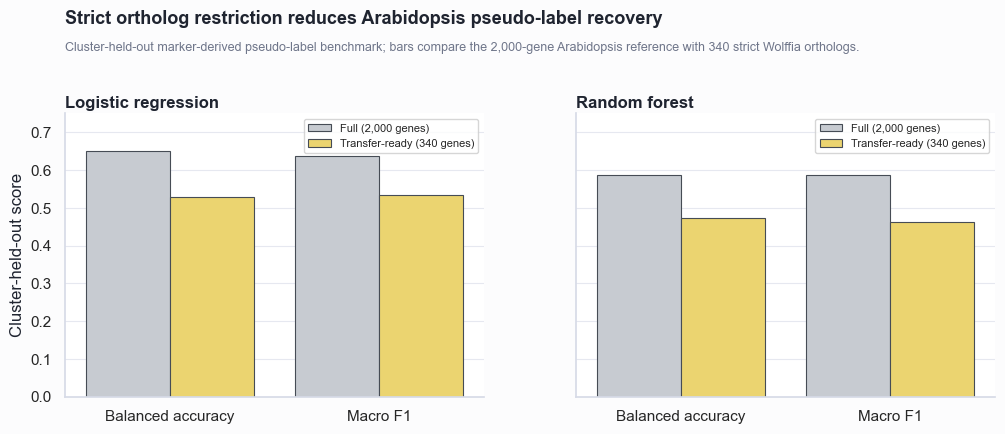

,feature_set,model,balanced_accuracy,macro_f1
0,"Full (2,000 genes)",Logistic regression,0.650,0.637
1,"Full (2,000 genes)",Random forest,0.588,0.586
2,Transfer-ready (340 genes),Logistic regression,0.528,0.535
3,Transfer-ready (340 genes),Random forest,0.474,0.463


In [4]:
metric_plot = model_metrics.loc[
    model_metrics["feature_set"].isin(["Full (2,000 genes)", "Transfer-ready (340 genes)"])
].copy()
metric_plot["model"] = metric_plot["model"].map({
    "logistic_regression": "Logistic regression",
    "random_forest": "Random forest",
})
long_metrics = metric_plot.melt(
    id_vars=["feature_set", "model"],
    value_vars=["balanced_accuracy", "macro_f1"],
    var_name="metric",
    value_name="score",
)
long_metrics["metric"] = long_metrics["metric"].map({
    "balanced_accuracy": "Balanced accuracy",
    "macro_f1": "Macro F1",
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, model_name in zip(axes, ["Logistic regression", "Random forest"]):
    subset = long_metrics.loc[long_metrics["model"].eq(model_name)]
    sns.barplot(
        data=subset, x="metric", y="score", hue="feature_set", ax=ax,
        palette={"Full (2,000 genes)": COLORS["neutral"], "Transfer-ready (340 genes)": COLORS["gold"]},
        edgecolor=COLORS["neutral_dark"], linewidth=0.8,
    )
    ax.text(0.0, 1.02, model_name, transform=ax.transAxes, fontweight="semibold", color=TOKENS["ink"])
    ax.set_xlabel("")
    ax.set_ylim(0, 0.75)
    ax.set_ylabel("Cluster-held-out score")
    ax.legend(title="", fontsize=8)
fig.subplots_adjust(top=0.74, wspace=0.22)
left = axes[0].get_position().x0
fig.text(left, 0.97, "Strict ortholog restriction reduces Arabidopsis pseudo-label recovery",
         ha="left", va="top", fontsize=13, fontweight="semibold", color=TOKENS["ink"])
fig.text(left, 0.90, "Cluster-held-out marker-derived pseudo-label benchmark; bars compare the 2,000-gene Arabidopsis reference with 340 strict Wolffia orthologs.",
         ha="left", va="top", fontsize=9, color=TOKENS["muted"])
for ax in axes:
    sns.despine(ax=ax)
plt.show()

display(metric_plot[["feature_set", "model", "balanced_accuracy", "macro_f1"]].style.format({
    "balanced_accuracy": "{:.3f}", "macro_f1": "{:.3f}"
}))

### 5. Confidence threshold tradeoff

Accuracy here is conditional on acceptance. The selected cutoff is not the point with the highest possible selective accuracy; it is the pre-data compromise between retaining a usable subset and sharply reducing incorrect pseudo-label assignments. The model's large `ambiguous` category is intentional.

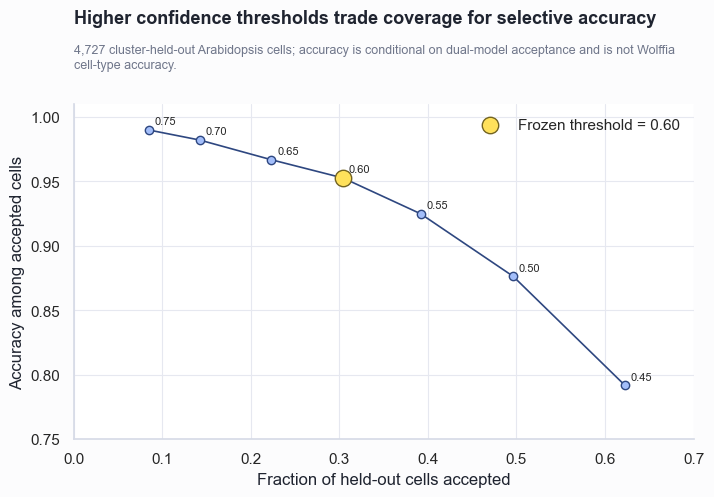

,confidence_threshold,n_cells,n_accepted,acceptance_rate,selective_accuracy,selective_balanced_accuracy,selective_macro_f1
0,0.45,4727,2943,62.3%,79.2%,54.0%,55.9%
1,0.50,4727,2346,49.6%,87.6%,60.8%,61.4%
2,0.55,4727,1852,39.2%,92.5%,67.0%,65.8%
3,0.60,4727,1438,30.4%,95.3%,70.7%,68.1%
4,0.65,4727,1056,22.3%,96.7%,72.8%,70.2%
5,0.70,4727,673,14.2%,98.2%,66.2%,62.7%
6,0.75,4727,400,8.5%,99.0%,99.5%,58.8%


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds["acceptance_rate"], thresholds["selective_accuracy"], marker="o", linewidth=1.2,
        color=COLORS["blue_dark"], markerfacecolor=COLORS["blue"], markeredgecolor=COLORS["blue_dark"])
for _, row in thresholds.iterrows():
    ax.annotate(f'{row["confidence_threshold"]:.2f}',
                (row["acceptance_rate"], row["selective_accuracy"]),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.scatter(frozen_row["acceptance_rate"], frozen_row["selective_accuracy"],
           s=140, color=COLORS["gold"], edgecolor=COLORS["gold_dark"], zorder=3, label="Frozen threshold = 0.60")
ax.set(
    xlabel="Fraction of held-out cells accepted",
    ylabel="Accuracy among accepted cells",
    xlim=(0, 0.70), ylim=(0.75, 1.01),
)
ax.legend(frameon=False)
add_chart_header(
    fig, ax,
    "Higher confidence thresholds trade coverage for selective accuracy",
    "4,727 cluster-held-out Arabidopsis cells; accuracy is conditional on dual-model acceptance and is not Wolffia cell-type accuracy.",
)
plt.show()

display(thresholds.style.format({
    "confidence_threshold": "{:.2f}",
    "acceptance_rate": "{:.1%}",
    "selective_accuracy": "{:.1%}",
    "selective_balanced_accuracy": "{:.1%}",
    "selective_macro_f1": "{:.1%}",
}))

### 6. Rejection behavior under controlled perturbations

Feature dropout is a proxy for incomplete cross-species measurement; Gaussian perturbation is a software stress scenario. A safe conservative model should generally accept fewer cells as evidence deteriorates. Accuracy in this panel must not be interpreted as generalization because the smoke-test cells contributed to fitting.

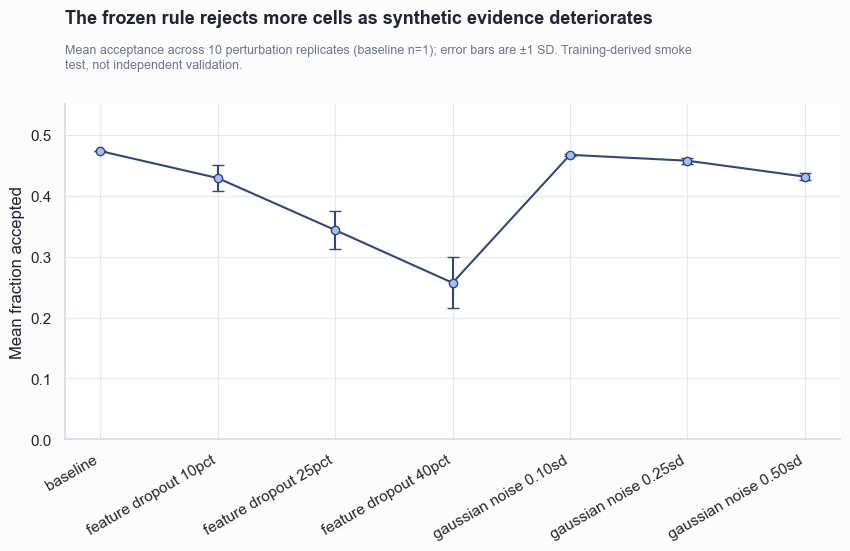

,scenario,acceptance_mean,acceptance_sd,selective_accuracy_mean,replicates
0,baseline,47.3%,0.0%,100.0%,1
1,feature_dropout_10pct,42.9%,2.1%,100.0%,10
2,feature_dropout_25pct,34.4%,3.1%,100.0%,10
3,feature_dropout_40pct,25.7%,4.2%,100.0%,10
4,gaussian_noise_0.10sd,46.7%,0.2%,100.0%,10
5,gaussian_noise_0.25sd,45.7%,0.5%,100.0%,10
6,gaussian_noise_0.50sd,43.1%,0.5%,100.0%,10


In [6]:
robust_summary = (
    robustness.groupby("scenario", sort=False)
    .agg(
        acceptance_mean=("acceptance_rate", "mean"),
        acceptance_sd=("acceptance_rate", "std"),
        selective_accuracy_mean=("selective_accuracy", "mean"),
        replicates=("replicate", "size"),
    )
    .reset_index()
)
robust_summary["acceptance_sd"] = robust_summary["acceptance_sd"].fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = robust_summary.copy()
plot_data["scenario_label"] = plot_data["scenario"].str.replace("_", " ", regex=False)
ax.errorbar(
    np.arange(len(plot_data)), plot_data["acceptance_mean"],
    yerr=plot_data["acceptance_sd"], fmt="o-", capsize=4, color=COLORS["blue_dark"], markerfacecolor=COLORS["blue"]
)
ax.set_xticks(np.arange(len(plot_data)), plot_data["scenario_label"], rotation=30, ha="right")
ax.set_ylim(0, 0.55)
ax.set_ylabel("Mean fraction accepted")
add_chart_header(
    fig, ax,
    "The frozen rule rejects more cells as synthetic evidence deteriorates",
    "Mean acceptance across 10 perturbation replicates (baseline n=1); error bars are ±1 SD. Training-derived smoke test, not independent validation.",
)
plt.show()

display(robust_summary.style.format({
    "acceptance_mean": "{:.1%}",
    "acceptance_sd": "{:.1%}",
    "selective_accuracy_mean": "{:.1%}",
}))

### 7. Program-level marker evidence

Strict reciprocal markers can support interpretation independently. Directional family matches remain review-only candidates and are never promoted automatically. The vascular program's lack of strict markers is a limitation of current orthology evidence—not evidence that vascular-like biology is absent from Wolffia.

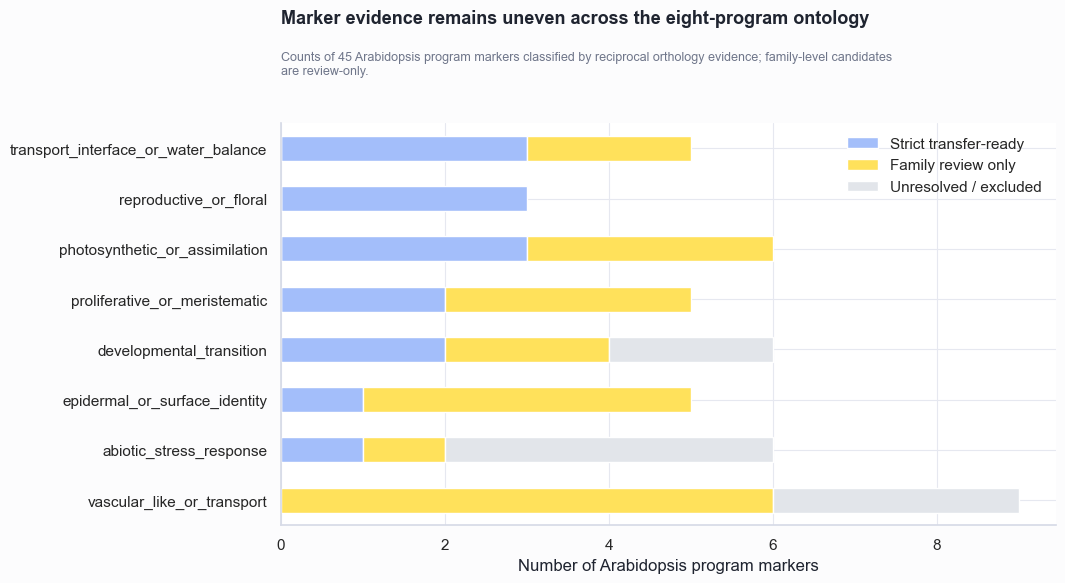

frozen_use,strict_transfer_ready,family_review_only,unresolved_excluded
program,,,
vascular_like_or_transport,0,6,3
abiotic_stress_response,1,1,4
epidermal_or_surface_identity,1,4,0
developmental_transition,2,2,2
proliferative_or_meristematic,2,3,0
photosynthetic_or_assimilation,3,3,0
reproductive_or_floral,3,0,0
transport_interface_or_water_balance,3,2,0


In [7]:
marker_counts = (
    markers.groupby(["program", "frozen_use"]).size().unstack(fill_value=0)
    .reindex(columns=["strict_transfer_ready", "family_review_only", "unresolved_excluded"], fill_value=0)
)
marker_counts = marker_counts.sort_values("strict_transfer_ready")
colors = [COLORS["blue"], COLORS["gold"], COLORS["neutral_light"]]
ax = marker_counts.plot(kind="barh", stacked=True, figsize=(10, 6), color=colors)
ax.set_xlabel("Number of Arabidopsis program markers")
ax.set_ylabel("")
ax.legend(["Strict transfer-ready", "Family review only", "Unresolved / excluded"], title="", frameon=False)
add_chart_header(
    ax.figure, ax,
    "Marker evidence remains uneven across the eight-program ontology",
    "Counts of 45 Arabidopsis program markers classified by reciprocal orthology evidence; family-level candidates are review-only.",
)
plt.show()

display(marker_counts)

### 8. Frozen decision contract

This is the machine-readable rule that the application script enforces. Marker support is deliberately a second-stage biological review because reliable Wolffia expression evidence is not available yet.

In [8]:
decision = manifest["decision_rule"]
decision_table = pd.DataFrame([
    ("Classifier feature space", f'{manifest["n_features"]} strict reciprocal orthologs'),
    ("Model agreement", "Required: logistic regression = random forest"),
    ("Minimum calibrated confidence", f'{decision["minimum_calibrated_confidence_each_model"]:.2f} for each model'),
    ("Minimum global feature coverage", f'{decision["minimum_global_feature_coverage"]:.0%}'),
    ("Rejected output", decision["otherwise"]),
    ("High-confidence biological label", decision["high_confidence_biological_annotation_also_requires"]),
], columns=["Component", "Frozen v1 rule"])
display(decision_table.style.hide(axis="index"))

Component,Frozen v1 rule
Classifier feature space,340 strict reciprocal orthologs
Model agreement,Required: logistic regression = random forest
Minimum calibrated confidence,0.60 for each model
Minimum global feature coverage,80%
Rejected output,ambiguous
High-confidence biological label,independent coherent marker-module support


## Takeaways

1. **Use the 340-feature model for Wolffia.** The 2,000-gene version remains an Arabidopsis-only benchmark.
2. **Use the two-model consensus, not either classifier alone.** Agreement plus calibrated confidence ≥0.60 provides the frozen provisional label.
3. **Expect ambiguity.** The held-out acceptance rate is 30.4%; conservative rejection is a feature of the design.
4. **Do not claim an eight-class classifier.** Version 1 predicts three root-derived coarse programs; the other programs are assessed through markers and unsupervised biology.
5. **Treat family-level markers cautiously.** They guide manual review and future orthogroup work but are excluded from strict prediction.
6. **Re-evaluate on real Wolffia data.** Dataset-derived QC, per-capture `scDblFinder`, ambient-RNA assessment, marker coherence, replicate stability, and validation on `PRJNA809022` are still required.

### Validation status

The notebook recomputes the headline acceptance and selective-accuracy numbers from the saved out-of-fold predictions, validates one-to-one model pairing, checks marker-table uniqueness, and displays artifact provenance. The model is **ready for provisional application with caveats**, not biologically validated.